ГРУППОВОЙ ПРОЕКТ №5. DEEP LEARNING

ноутбук 3: определение категории товара по фото - сверточные нейронные сети

ПОСТАНОВКА ЗАДАЧИ

вторая бизнес-задача из ноутбука 1: продавец загружает фото товара, модель сама предлагает категорию для карточки. сейчас категорию выбирают руками и ошибаются, а от нее зависит поиск, фильтры и рекомендации

на языке DL это многоклассовая классификация изображений: по фото 60x80 предсказываем articleType. по EDA берем топ-20 типов товаров - это 74.6% каталога, 33 тыс размеченных фото. лосс - кросс-энтропия, метрики - точность и macro F1 (классы несбалансированы, Tshirts в 11 раз больше чем Jeans, поэтому одна только точность обманчива)

сравниваем 5 архитектур: от полносвязного перцептрона (он тут для того же что наивный прогноз в ноутбуке 2 - показать сколько добавляют именно свертки) до предобученного ResNet18. все эксперименты в wandb с метриками по эпохам

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# картинки читаем PIL, на семинарах был cv2 но тут без разницы
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix

os.environ['WANDB_SILENT'] = 'true'
import wandb

ДАННЫЕ

берем датасет с фото из ноутбука 1, оставляем топ-20 категорий и только товары у которых есть файл картинки

In [2]:
os.environ['KAGGLEHUB_CACHE'] = os.path.abspath('../data/kagglehub')

import kagglehub

images_path = kagglehub.dataset_download('paramaggarwal/fashion-product-images-small')

styles = pd.read_csv(os.path.join(images_path, 'styles.csv'), on_bad_lines='skip')
img_ids = [int(f.split('.')[0]) for f in os.listdir(os.path.join(images_path, 'images'))]
styles = styles[styles['id'].isin(img_ids)]

top20 = styles['articleType'].value_counts().head(20)
sub = styles[styles['articleType'].isin(top20.index)].reset_index(drop=True)
len(sub)

33142

In [3]:
classes = list(top20.index)
cls2idx = {c: i for i, c in enumerate(classes)}
y = np.array(sub['articleType'].apply(lambda c: cls2idx[c]))
len(classes)

20

фото у всех товаров 60x80, для сетей приводим к единому размеру 64x64 (минимум который переваривает AlexNet) и грузим все в один массив - картинки маленькие, 33 тыс штук влезают в память целиком и обучение не упирается в чтение с диска

In [4]:
images = np.zeros((len(sub), 64, 64, 3), dtype=np.uint8)
for i, img_id in enumerate(sub['id'].values):
    im = Image.open(os.path.join(images_path, 'images', str(img_id) + '.jpg')).convert('RGB').resize((64, 64))
    images[i] = np.array(im)

images.shape

(33142, 64, 64, 3)

In [5]:
idx_train, idx_tmp = train_test_split(np.arange(len(y)), test_size=0.3, random_state=2026, stratify=y)
idx_val, idx_test = train_test_split(idx_tmp, test_size=0.5, random_state=2026, stratify=y[idx_tmp])

len(idx_train), len(idx_val), len(idx_test)

(23199, 4971, 4972)

делим 70/15/15 со стратификацией по классу, чтобы доли категорий в трех выборках совпадали. и сразу точка отсчета: самый частый класс

In [6]:
pd.Series(y[idx_test]).value_counts(normalize=True).round(3).head(3)

0    0.213
1    0.097
2    0.086
Name: proportion, dtype: float64

если на любое фото отвечать 'Tshirts', точность будет около 21% - это планка для нейросетей. перцептрон и свертки обязаны быть сильно выше

ДАТАСЕТ И ЗАГРУЗЧИКИ

картинки храним как uint8, а в float и нормировку переводим на лету в Dataset (как делали пайплайны в семинаре 20-21). нормируем под статистики ImageNet - этого требуют предобученные AlexNet и ResNet, а обычным сверткам без разницы какие константы

In [7]:
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


class FashionDataset(Dataset):
    def __init__(self, imgs, labels):
        self.imgs = imgs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        img = torch.from_numpy(self.imgs[i]).permute(2, 0, 1).float() / 255
        img = (img - mean_t) / std_t
        return img, self.labels[i]

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

train_loader = DataLoader(FashionDataset(images[idx_train], y[idx_train]), batch_size=128, shuffle=True)
val_loader = DataLoader(FashionDataset(images[idx_val], y[idx_val]), batch_size=512)
test_loader = DataLoader(FashionDataset(images[idx_test], y[idx_test]), batch_size=512)
device

device(type='mps')

данные эксперимента грузим в wandb артефактом: один файл с картинками, метками, списком классов и индексами разбиения, плюс манифест csv. любой эксперимент этого ноутбука воспроизводится только из wandb

In [9]:
os.makedirs('../data/processed', exist_ok=True)

torch.save({'images': images, 'labels': y, 'classes': classes,
            'idx_train': idx_train, 'idx_val': idx_val, 'idx_test': idx_test},
           '../data/processed/images_dataset.pt')

manifest = sub[['id', 'articleType']].copy()
manifest['split'] = 'train'
manifest.loc[idx_val, 'split'] = 'val'
manifest.loc[idx_test, 'split'] = 'test'
manifest.to_csv('../data/processed/images_manifest.csv', index=False)

run = wandb.init(project='gp5-fashion-dl', name='images-data-upload', job_type='dataset')
art = wandb.Artifact('images-data', type='dataset', description='фото 64x64 uint8, метки топ-20 категорий, разбиение train/val/test')
art.add_file('../data/processed/images_dataset.pt')
art.add_file('../data/processed/images_manifest.csv')
run.log_artifact(art)
run.finish()

ФУНКЦИИ ОБУЧЕНИЯ

те же что в ноутбуке 2, только под классификацию: лосс кросс-энтропия, метрика - точность. run_experiment логирует в wandb метрики каждой эпохи и сохраняет модель артефактом

In [10]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [11]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total, correct = 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(yb)
        correct += (out.argmax(1) == yb).sum().item()
    return total / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            total += criterion(out, yb).item() * len(yb)
            correct += (out.argmax(1) == yb).sum().item()
    return total / len(loader.dataset), correct / len(loader.dataset)


def predict(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(device)).argmax(1).cpu())
    return torch.cat(preds).numpy()

In [12]:
def run_experiment(name, model, config):
    run = wandb.init(project='gp5-fashion-dl', name=name, config=config)
    run.use_artifact('images-data:latest')

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(config['epochs']):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion)
        vl, va = evaluate(model, val_loader, criterion)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        run.log({'epoch': epoch + 1, 'train_loss': tl, 'train_acc': ta, 'val_loss': vl, 'val_acc': va})

    path = '../models/' + name + '.pt'
    torch.save(model.state_dict(), path)
    art = wandb.Artifact(name, type='model')
    art.add_file(path)
    run.log_artifact(art)
    run.finish()
    return history

АРХИТЕКТУРА 1: ПЕРЦЕПТРОН

полносвязная сеть на развернутых в вектор пикселях (12288 -> 512 -> 256 -> 20). как в семинарах 18-19, где перцептрон сражался с CNN на CIFAR - он игнорирует пространственную структуру картинки и работает с пикселями как с независимыми признаками. это базовая отметка: разница между ним и свертками покажет сколько стоит именно сверточная архитектура

In [13]:
seed_everything(2026)

model_1 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 64 * 64, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 20)
).to(device)

config_1 = {'arch': 'perceptron 512-256', 'pretrained': False, 'optimizer': 'Adam', 'lr': 1e-3,
            'batch_size': 128, 'epochs': 8, 'input': '64x64', 'n_classes': 20, 'seed': 2026}

hist_1 = run_experiment('cnn-1-perceptron', model_1, config_1)
round(max(hist_1['val_acc']), 3)

0.829

точность 82.9% на валидации против 21% у наивного. даже перцептрон тут что-то умеет. фото студийные, фон белый, товар по центру, поэтому даже голые пиксели несут много информации. но видно что это потолок. val лосс 0.66 при train 0.41, сеть зубрит трейн а обобщает так себе

АРХИТЕКТУРА 2: ПРОСТАЯ СВЕРТОЧНАЯ СЕТЬ

три сверточных блока (16-32-64 каналов, ядро 3x3) с max-пулингом, потом два полносвязных слоя - по образцу CIFAR_Net из семинара 18. свертки видят локальные сочетания пикселей и не зависят от положения объекта в кадре

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 20)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [15]:
seed_everything(2026)

model_2 = SimpleCNN().to(device)

config_2 = {'arch': 'conv16-32-64 + fc256', 'pretrained': False, 'optimizer': 'Adam', 'lr': 1e-3,
            'batch_size': 128, 'epochs': 8, 'input': '64x64', 'n_classes': 20, 'seed': 2026}

hist_2 = run_experiment('cnn-2-simple', model_2, config_2)
round(max(hist_2['val_acc']), 3)

0.901

свертки дают +7 п.п. к перцептрону (90.1% против 82.9%) и это при параметрах в 6 раз меньше, 1.1 млн против 6.4 - вот цена учета пространственной структуры. переобучение правда заметное: на трейне 94.7%, на валидации 90.1%

АРХИТЕКТУРА 3: CNN + BATCHNORM + DROPOUT

сверточная сеть пошире (32-64-128) и с техниками из семинара 19: BatchNorm2d после каждой свертки и Dropout перед классификатором. ожидаем более стабильное обучение и меньший разрыв train/val

In [16]:
class CNNRegularized(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 20)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

In [17]:
seed_everything(2026)

model_3 = CNNRegularized().to(device)

config_3 = {'arch': 'conv32-64-128 + BN + dropout', 'pretrained': False, 'optimizer': 'Adam', 'lr': 1e-3,
            'batch_size': 128, 'epochs': 8, 'input': '64x64', 'n_classes': 20, 'seed': 2026}

hist_3 = run_experiment('cnn-3-bn-dropout', model_3, config_3)
round(max(hist_3['val_acc']), 3)

0.912

лучшая из сетей с нуля: 91.2%. BatchNorm разогнал старт - 84.2% уже после первой эпохи против 79.8% у простой CNN, и разрыв train/val сократился до пары процентов (92.4% против 91.2%). занятно что на табличной задаче регуляризация ничего не дала, а тут честно отработала - видимо потому что у сверточной сети на картинках есть что регуляризовать

АРХИТЕКТУРА 4: TRANSFER LEARNING, ALEXNET

как в семинаре 19: берем AlexNet предобученный на ImageNet, замораживаем сверточную часть (она уже умеет видеть края, текстуры, формы) и учим только классификатор под наши 20 классов. learning rate для дообучения ставим поменьше (1e-4), чтобы не разломать предобученные веса

In [18]:
from torchvision.models import alexnet, AlexNet_Weights

seed_everything(2026)

model_4 = alexnet(weights=AlexNet_Weights.DEFAULT)
for p in model_4.features.parameters():
    p.requires_grad = False
model_4.classifier[6] = nn.Linear(4096, 20)
model_4 = model_4.to(device)

config_4 = {'arch': 'alexnet (frozen features)', 'pretrained': True, 'optimizer': 'Adam', 'lr': 1e-4,
            'batch_size': 128, 'epochs': 8, 'input': '64x64', 'n_classes': 20, 'seed': 2026}

hist_4 = run_experiment('cnn-4-alexnet-transfer', model_4, config_4)
round(max(hist_4['val_acc']), 3)

0.842

неожиданно слабо, 84.2%. хуже обеих сверток с нуля, а мы то ставили на то что предобученная сеть всех порвет. причин видимо две. во-первых вход 64x64 сильно меньше родных 224x224 на которых AlexNet учился. во-вторых замороженые ImageNet признаки заточены под обычные фотографии а у нас студийные карточки на белом фоне. transfer learning не магия. когда своих данных много (23 тыс) а домен специфичный, сеть с нуля выигрывает у замороженного гиганта

АРХИТЕКТУРА 5: FINE-TUNING, RESNET18

архитектура которой не было на семинарах - ResNet18. главная идея резнетов - остаточные связи (skip connections): блок учит не само преобразование а поправку к нему, и это позволяет тренировать глубокие сети без затухания градиентов. сеть сильно глубже AlexNet (18 слоев) но при этом легче по параметрам

в отличие от конфига 4 дообучаем не только голову а все слои целиком (fine-tuning), тоже с маленьким lr 1e-4. меняем последний слой под 20 классов

In [19]:
# resnet18 с предобученными весами ImageNet
from torchvision.models import resnet18, ResNet18_Weights

seed_everything(2026)

model_5 = resnet18(weights=ResNet18_Weights.DEFAULT)
model_5.fc = nn.Linear(512, 20)
model_5 = model_5.to(device)

config_5 = {'arch': 'resnet18 (full fine-tune)', 'pretrained': True, 'optimizer': 'Adam', 'lr': 1e-4,
            'batch_size': 128, 'epochs': 8, 'input': '64x64', 'n_classes': 20, 'seed': 2026}

hist_5 = run_experiment('cnn-5-resnet18', model_5, config_5)
round(max(hist_5['val_acc']), 3)

0.921

лучший результат: 92.1% на валидации, причем 90.1% уже после первой эпохи - предобученные веса при полном дообучении дают мощнейший старт. к 8 эпохе train acc 99.1%, сеть выучила трейн почти наизусть, дольше учить смысла нет. сравнение с конфигом 4 показательно: тот же ImageNet, но дообучение всех слоев против заморозки - и разница 8 п.п.

СРАВНЕНИЕ АРХИТЕКТУР

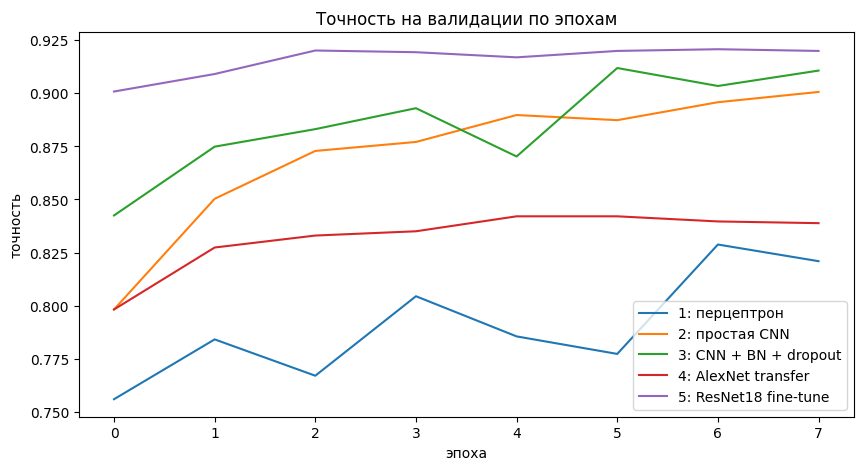

In [20]:
plt.figure(figsize=(10, 5))
for hist, label in [(hist_1, '1: перцептрон'), (hist_2, '2: простая CNN'),
                    (hist_3, '3: CNN + BN + dropout'), (hist_4, '4: AlexNet transfer'),
                    (hist_5, '5: ResNet18 fine-tune')]:
    plt.plot(hist['val_acc'], label=label)
plt.title('Точность на валидации по эпохам')
plt.xlabel('эпоха')
plt.ylabel('точность')
plt.legend()
plt.show()

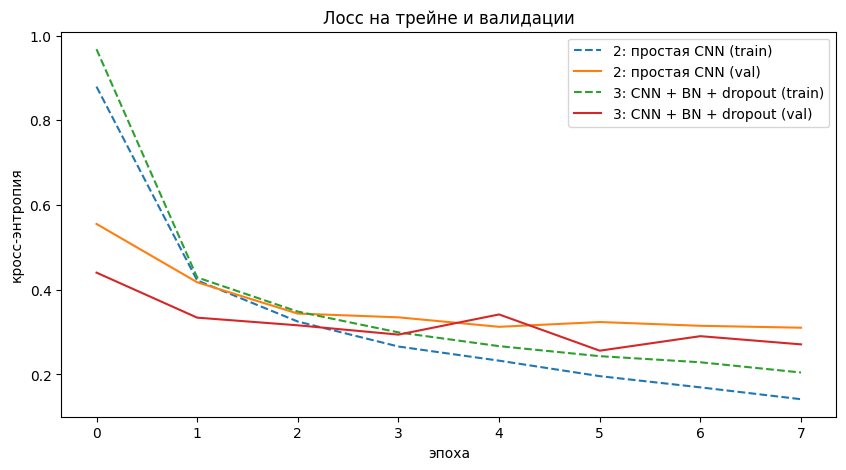

In [21]:
plt.figure(figsize=(10, 5))
for hist, label in [(hist_2, '2: простая CNN'), (hist_3, '3: CNN + BN + dropout')]:
    plt.plot(hist['train_loss'], '--', label=label + ' (train)')
    plt.plot(hist['val_loss'], label=label + ' (val)')
plt.title('Лосс на трейне и валидации')
plt.xlabel('эпоха')
plt.ylabel('кросс-энтропия')
plt.legend()
plt.show()

финальное сравнение на тесте: точность и macro F1 (среднее F1 по классам, каждый класс с одинаковым весом - редкие категории не прячутся за Tshirts)

In [22]:
y_true = y[idx_test]

rows = []
for name, model, hist in [('1: перцептрон', model_1, hist_1),
                          ('2: простая CNN', model_2, hist_2),
                          ('3: CNN + BN + dropout', model_3, hist_3),
                          ('4: AlexNet transfer', model_4, hist_4),
                          ('5: ResNet18 fine-tune', model_5, hist_5)]:
    pred = predict(model, test_loader)
    n_params = sum(p.numel() for p in model.parameters())
    rows.append([name, n_params, round(max(hist['val_acc']), 3),
                 round((pred == y_true).mean(), 3), round(f1_score(y_true, pred, average='macro'), 3)])

results = pd.DataFrame(rows, columns=['архитектура', 'параметров', 'best val acc', 'test acc', 'test macro F1'])
results

,архитектура,параметров,best val acc,test acc,test macro F1
0,1: перцептрон,6428436,0.829,0.824,0.820
1,2: простая CNN,1077556,0.901,0.900,0.905
2,3: CNN + BN + dropout,2196244,0.912,0.910,0.915
3,4: AlexNet transfer,57085780,0.842,0.835,0.843
4,5: ResNet18 fine-tune,11186772,0.921,0.920,0.924


итоговый расклад на тесте: перцептрон 82.4%, свертки с нуля 90.0-91.0%, замороженный AlexNet 83.5%, дообученный ResNet18 - 92.0% и macro F1 0.924

выводы из сравнения:

- свертки против пикселей: +8 п.п. точности при меньшем числе параметров - пространственная структура решает
- BatchNorm+Dropout добавляют процент и убирают переобучение
- transfer learning работает только с адаптацией. замороженный AlexNet проиграл даже простой CNN, а полностью дообученный ResNet18 выиграл у всех. дело не в том предобучена сеть или нет, а в том дали ли ей подстроиться под домен
- macro F1 у всех близок к точности. редкие классы не задавлены частыми, стратификация и 600+ примеров на класс этого хватило

РАЗБОР ЛУЧШЕЙ МОДЕЛИ

смотрим где лучшая модель ошибается: матрица ошибок по классам (нормирована по строкам - доля от реального класса) и самые частые путаницы

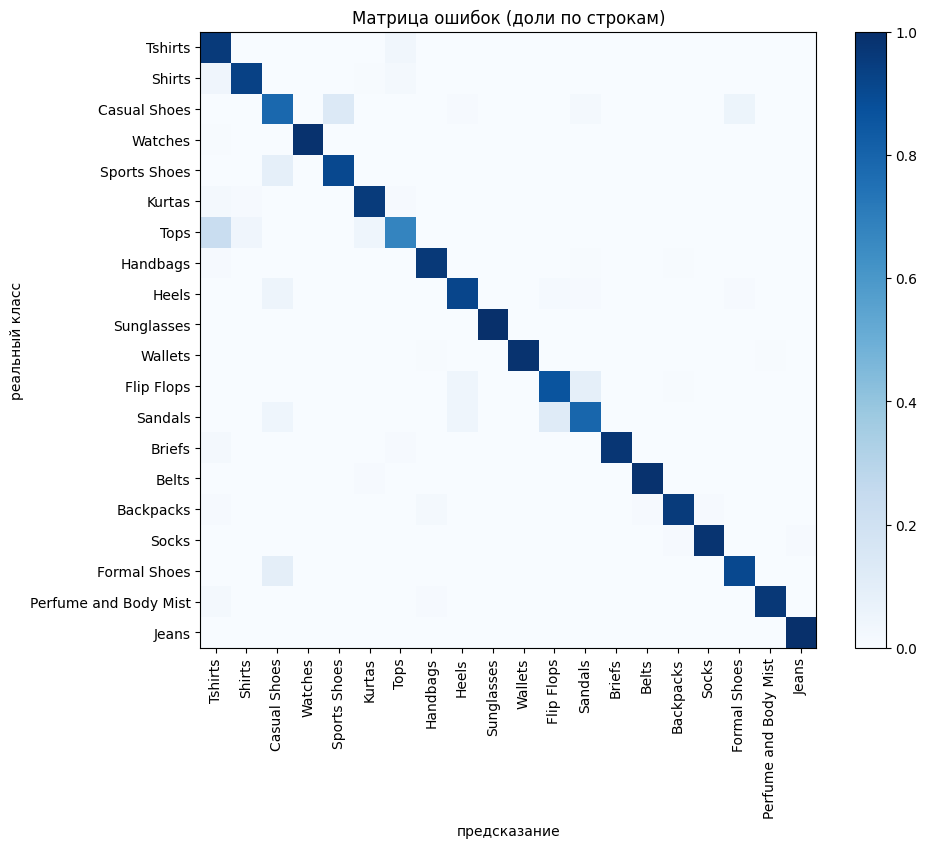

In [23]:
pred_best = predict(model_5, test_loader)

cm = confusion_matrix(y_true, pred_best, normalize='true')

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(20), classes, rotation=90)
plt.yticks(range(20), classes)
plt.title('Матрица ошибок (доли по строкам)')
plt.xlabel('предсказание')
plt.ylabel('реальный класс')
plt.show()

In [24]:
cm_raw = confusion_matrix(y_true, pred_best)

pairs = []
for i in range(20):
    for j in range(20):
        if i != j and cm_raw[i, j] > 0:
            pairs.append([classes[i], classes[j], cm_raw[i, j]])

pd.DataFrame(pairs, columns=['реальный', 'предсказали', 'ошибок']).sort_values('ошибок', ascending=False).head(10)

,реальный,предсказали,ошибок
22,Tops,Tshirts,62
10,Casual Shoes,Sports Shoes,58
2,Tshirts,Tops,36
17,Sports Shoes,Casual Shoes,27
13,Casual Shoes,Formal Shoes,22
7,Shirts,Tshirts,20
43,Sandals,Flip Flops,16
24,Tops,Kurtas,12
39,Flip Flops,Sandals,12
23,Tops,Shirts,11


ошибки осмысленные: модель путает ровно то, что и человек путал бы на фото 64 пикселя - Tops с Tshirts (62 и 36 ошибок в обе стороны), Casual Shoes со Sports Shoes (58 и 27), Sandals с Flip Flops. это не случайный шум, а пары соседних категорий с размытой границей

по матрице видно что диагональ почти везде темная - большинство классов узнаются с точностью сильно за 90%

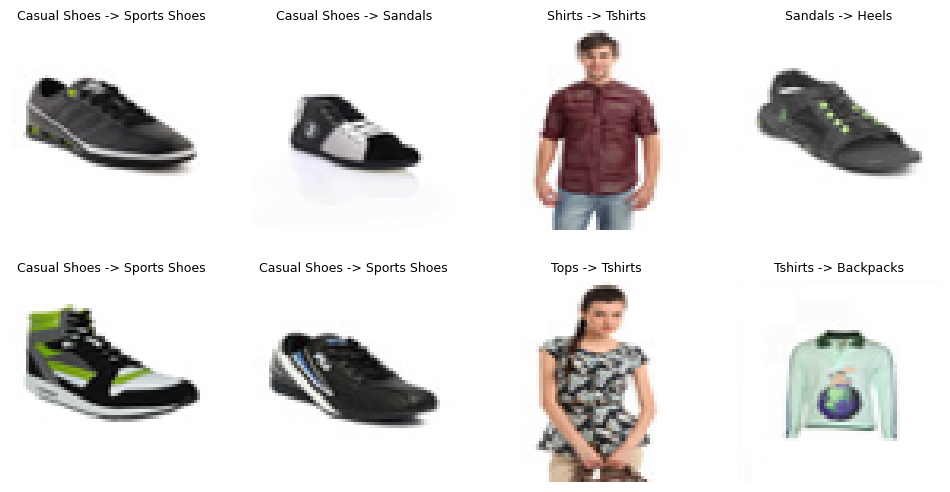

In [25]:
wrong = np.where(pred_best != y_true)[0]

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    idx = idx_test[wrong[i]]
    plt.imshow(images[idx])
    plt.title(classes[y_true[wrong[i]]] + ' -> ' + classes[pred_best[wrong[i]]], fontsize=9)
    plt.axis('off')
plt.show()

на примерах видно что многие ошибки простительные - часть таких товаров и человек отнес бы к соседней категории, а кое-где спорна сама разметка в данных. систематических провалов (типа 'все часы называет сумками') нет

ИТОГИ ПО ЗАДАЧЕ С ФОТО

что сделали: собрали датасет из 33 тыс фото топ-20 категорий (74.6% каталога), обучили и сравнили 5 архитектур - перцептрон, две сверточные сети с нуля, замороженный AlexNet и дообученный ResNet18. каждый эксперимент - отдельный запуск в wandb с метриками по эпохам и артефактом модели, сам датасет тоже лежит в wandb артефактом

главные выводы:

- задача решается уверенно. ResNet18 дает 92% точности и macro F1 0.924 против 21% у наивного
- свертки оправдывают себя. +8 п.п. над перцептроном и при меньших параметрах
- регуляризация на картинках работает (+1 п.п. и стабильность). на табличной задаче она ничего не дала, а тут да
- transfer learning неоднозначен. замороженный AlexNet проиграл сверткам с нуля (83.5% против 90-91%), вход 64x64 и студийные фото далеки от ImageNet. а полное дообучение ResNet18 выиграло у всех. предобученность полезна только с адаптацией под домен
- ошибки сидят в парах соседних категорий. Tops-Tshirts, Casual-Sports Shoes, Sandals-Flip Flops

бизнес-рекомендация: включать автокатегоризацию в форму заведения карточки - 92% точности при мгновенном ответе. для путающихся пар показывать продавцу топ-2 варианта на выбор а не один. вместе с моделью цены из ноутбука 2 складывается законченный пайплайн: загрузил фото - получил категорию, заполнил атрибуты - получил рекомендованную цену, продавцу остается подтвердить